# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

## Who
The primary audience is lending institutions, credit-risk managers, loan underwriters, and portfolio managers. These stakeholders need to make informed lending decisions while balancing two competing objectives: reducing losses from borrowers who fail to repay and avoiding the rejection of creditworthy applicants. The analysis will help lenders improve loan-approval policies, identify higher-risk loans, and determine when additional review or risk-management measures may be appropriate.

## What
The analysis will examine which borrower, application, credit-history, and loan characteristics are most strongly associated with negative repayment outcomes.

Across the datasets, a negative outcome may be defined differently, including:

Experiencing payment difficulties during the early stages of a loan
Defaulting on a mortgage or other loan
Having a loan charged off or recorded as defaulted
The analysis will evaluate factors such as income, credit score, debt-to-income ratio, loan amount, interest rate, employment history, loan purpose, credit history, and repayment behavior. The goal is to estimate each borrower’s probability of default or payment difficulty and identify the characteristics most useful for predicting credit risk.

## How
First, the datasets will be cleaned and prepared by handling missing values, removing duplicates, encoding categorical variables, and creating useful measures such as credit-to-income and payment-to-income ratios. Because the datasets define default differently, each model will use the appropriate target variable for its dataset while comparing common risk patterns across lenders.

Clear visualizations will communicate important findings, including default rates by credit score, income, debt-to-income ratio, loan grade, loan type, and other relevant borrower characteristics.

Logistic regression will serve as an interpretable baseline model. Its coefficients and odds ratios will help explain which characteristics are associated with higher or lower default risk while accounting for other variables.

A random forest model will then be used to identify nonlinear patterns and interactions among multiple risk factors. Permutation importance or SHAP values will help explain which variables contribute most strongly to its predictions.

Model performance will be evaluated using ROC-AUC, precision, recall, confusion matrices, and precision-recall curves. Because defaults are less common than successful repayments, accuracy alone will not be used to judge model quality. The analysis will also avoid data leakage, evaluate potential bias, and treat identified relationships as associations rather than proof of causation.



# 3. Homework - work with your own data

In [100]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

## ALL LENDING CLUB LOAN DATA ##

In [101]:
# LOADING THE DATASETS 

DATA_DIR = Path("/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/All Lending Club Loan Data")

Accepted_Lending_Club_Data= pd.read_csv(DATA_DIR / "accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", encoding="latin1")
Rejected_Lending_Club_Data = pd.read_csv(DATA_DIR / "rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv")


/var/folders/mv/spx6wvr963x933gjcq0392n80000gn/T/ipykernel_25975/1348182421.py:5: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  Accepted_Lending_Club_Data= pd.read_csv(DATA_DIR / "accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv", encoding="latin1")


In [102]:
# ALL LENDING CLUB LOAN DATA


# ACCEPTED DATASET
# Displaying info and describing the dataset
Accepted_Lending_Club_Data.info()
Accepted_Lending_Club_Data.describe()

# # Mean, median, mode 
Accepted_Lending_Club_Data.mean(numeric_only = True)
Accepted_Lending_Club_Data.median(numeric_only = True) 
Accepted_Lending_Club_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Accepted_Lending_Club_Data.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

Accepted_Lending_Club_Data.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 

Accepted_Lending_Club_Data.isnull().any().sum() # there are 150 columns with a null value in the dataset

Accepted_Lending_Club_Data.shape


# REJECTED DATASET 
# Displaying info and describing the dataset
Rejected_Lending_Club_Data.info()
Rejected_Lending_Club_Data.describe()

# # Mean, median, mode of each column 
Rejected_Lending_Club_Data.mean(numeric_only = True)
Rejected_Lending_Club_Data.median(numeric_only = True) 
Rejected_Lending_Club_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Rejected_Lending_Club_Data.duplicated().any() # there are 157954 duplicated rows in the dataset
Rejected_Lending_Club_Data.duplicated().sum() # there are 157954 duplicated rows in the dataset

# Checking null values in the columns 
Rejected_Lending_Club_Data.isnull().any().sum() # there are 6 columns with null values in the dataset


<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 3.0+ GB
<class 'pandas.DataFrame'>
RangeIndex: 27648741 entries, 0 to 27648740
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      str    
 2   Loan Title            str    
 3   Risk_Score            float64
 4   Debt-To-Income Ratio  str    
 5   Zip Code              str    
 6   State                 str    
 7   Employment Length     str    
 8   Policy Code           float64
dtypes: float64(3), str(6)
memory usage: 3.0 GB


np.int64(6)

## Lending Club Data Summary and Conclusions
This analysis examined the accepted and rejected Lending Club datasets to understand their structure, identify data-quality problems, and determine whether they are suitable for future credit-risk analysis.

The accepted-loan dataset contains 2,260,701 records and 151 columns. It includes detailed borrower, loan, credit-history, and repayment information. The rejected-loan dataset contains 27,648,741 records and 9 columns, providing limited information about applicants who were denied loans.

The summary statistics reveal the typical values and distributions of the numerical variables. The mean and median help identify potentially skewed variables and unusual values, while the mode identifies the most common values. Additional investigation is needed to determine whether missing values or extreme values could affect the analysis.

Neither dataset contains completely duplicated rows. However, missing data are common: 150 accepted-loan columns and 6 rejected-loan columns contain at least one missing value. These values must be evaluated before modeling because some columns may require imputation or removal.

Overall, both datasets are usable, but they support different analyses. The accepted dataset is most appropriate for predicting default because it includes repayment outcomes. The rejected dataset can be used to examine patterns among denied applicants, but it cannot determine whether those applicants would have defaulted. Before modeling, categorical variables must be encoded, missing values handled, inconsistent values investigated, and the target variable checked for class imbalance.

##  HOME CREDIT DEFAULT RISK DATASET ## 

## Dataset Descriptions for Home Credit Default Risk ##

application_train.csv
This is the main dataset for analysis. Includes the target column

HomeCredit_columns_description.csv
Data dictionary. Helps explain weird column names.

bureau.csv
Previous credit history from other banks/lenders.

previous_application.csv
Previous Home Credit applications.

installments_payments.csv
Payment history on previous Home Credit loans.

credit_card_balance.csv
Credit card balance history.

POS_CASH_balance.csv
Monthly balance history for point-of-sale/cash loans.

bureau_balance.csv
Monthly history for bureau records.

sample_submission.csv
Only for Kaggle competition formatting.

In [103]:

DATA_DIR = Path("/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/home-credit-default-risk")

Home_Credit_app = pd.read_csv(DATA_DIR / 'previous_application.csv')
Home_Credit_app_TEST = pd.read_csv(DATA_DIR / 'application_test.csv')
Home_Credit_app_TRAIN = pd.read_csv(DATA_DIR / 'application_train.csv') # this is the main analysis dataset in the material 

Home_Credit_bureau = pd.read_csv(DATA_DIR / "bureau.csv")
Home_Credit_credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
Home_Credit_POS_CASH_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")


In [104]:
# Home Credit App_TRAIN (Main Dataset for Analysis)

# Data types and describing the data 
Home_Credit_app_TRAIN.info()
Home_Credit_app_TRAIN.describe()
Home_Credit_app_TRAIN.shape # dataset has 307511 rows and 122 columns 



# # Mean, median, mode of each column 
Home_Credit_app_TRAIN.mean(numeric_only = True)
Home_Credit_app_TRAIN.median(numeric_only = True) 
Home_Credit_app_TRAIN.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Home_Credit_app_TRAIN.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

Home_Credit_app_TRAIN.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 

# Checking the columns of the dataset
Home_Credit_app_TRAIN.isnull().any().sum() # there are 67 columns with null values in the dataset


(Home_Credit_app_TRAIN['TARGET'] ==1).sum() #24825 have payment difficulties target = 1
(Home_Credit_app_TRAIN['TARGET'] ==1).sum() / ((Home_Credit_app_TRAIN['TARGET'] ==1).sum() + (Home_Credit_app_TRAIN['TARGET'] ==0).sum()) # approx 8.1% have payment difficulties target = 1

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


np.float64(0.08072881945686496)

In [105]:
# Checking the Values of Target Columns 

status_df = Home_Credit_app_TRAIN['TARGET'].value_counts().reset_index()
status_df.columns = ['Status', 'Count']

status_df['Status'] = status_df['Status'].map({1: 'Payment Difficulties Occured After Approval', 
                                               0: 'Payment Difficulties Occured'})

status_df['Percentage'] = (status_df['Count']/status_df['Count'].sum() * 100)

status_df.loc[len(status_df)] = ['Total', 
                                 status_df['Count'].sum(), 
                                 status_df['Percentage'].sum()]

status_df

,Status,Count,Percentage
0,Payment Difficulties Occured,282686,91.927118
1,Payment Difficulties Occured After Approval,24825,8.072882
2,Total,307511,100.000000


In [106]:
# Encoding the Categorical Variable Types for Analysis 

X = Home_Credit_app_TRAIN.select_dtypes(exclude = 'number')
encoder = OrdinalEncoder()
encoded_df = encoder.fit_transform(X) 

Home_Credit_app_TRAIN_encoded = Home_Credit_app_TRAIN.copy()
Home_Credit_app_TRAIN_encoded[X.columns] = encoded_df
Home_Credit_app_TRAIN_encoded.head()

# checking the values of the categorical encoded columns 

for column, categories in zip(X.columns, encoder.categories_):
    print(f"\n{column}")
    for code, category in enumerate(categories):
        print(f"{category} -> {code}")


NAME_CONTRACT_TYPE
Cash loans -> 0
Revolving loans -> 1

CODE_GENDER
F -> 0
M -> 1
XNA -> 2

FLAG_OWN_CAR
N -> 0
Y -> 1

FLAG_OWN_REALTY
N -> 0
Y -> 1

NAME_TYPE_SUITE
Children -> 0
Family -> 1
Group of people -> 2
Other_A -> 3
Other_B -> 4
Spouse, partner -> 5
Unaccompanied -> 6
nan -> 7

NAME_INCOME_TYPE
Businessman -> 0
Commercial associate -> 1
Maternity leave -> 2
Pensioner -> 3
State servant -> 4
Student -> 5
Unemployed -> 6
Working -> 7

NAME_EDUCATION_TYPE
Academic degree -> 0
Higher education -> 1
Incomplete higher -> 2
Lower secondary -> 3
Secondary / secondary special -> 4

NAME_FAMILY_STATUS
Civil marriage -> 0
Married -> 1
Separated -> 2
Single / not married -> 3
Unknown -> 4
Widow -> 5

NAME_HOUSING_TYPE
Co-op apartment -> 0
House / apartment -> 1
Municipal apartment -> 2
Office apartment -> 3
Rented apartment -> 4
With parents -> 5

OCCUPATION_TYPE
Accountants -> 0
Cleaning staff -> 1
Cooking staff -> 2
Core staff -> 3
Drivers -> 4
HR staff -> 5
High skill tech staff ->

## Home Credit Application Data Summary and Conclusions
This analysis examined the Home Credit training dataset to understand its structure, summarize its variables, identify data-quality concerns, and determine whether it is suitable for predicting payment difficulties.

The dataset contains 307,511 loan applications and 122 columns. These columns include applicant demographics, income, employment history, loan characteristics, housing information, external credit scores, and the target variable TARGET.

The mean, median, and mode provide an initial understanding of the dataset’s distributions and most common values. Differences between means and medians may identify skewed variables, extreme values, or potential outliers requiring further investigation.

The dataset contains no completely duplicated rows, indicating that each application record is unique. However, 67 of the 122 columns contain at least one missing value. The amount and importance of missing data in each column should be evaluated before deciding whether to fill missing values or remove certain features.

Overall, the dataset is suitable for predicting payment difficulties because it contains a clearly defined target variable. Before modeling, missing values must be handled, categorical variables encoded, unusual values investigated, and class imbalance addressed because only approximately 8.1% of applications have TARGET = 1. Accuracy alone should therefore not be used to evaluate model performance.

## LOAN DEFAULT DATA ##

In [107]:
Loan_Default_Data = pd.read_csv('/Users/calvinbaker/AI_For_Leaders_Module-B-semester-2/DATA/Loan_Default.csv')

In [108]:
# Loan Default Data 

# Data types and describing the data 
Loan_Default_Data.info()
Loan_Default_Data.describe()

# # Mean, median, mode of each column 
Loan_Default_Data.mean(numeric_only = True)
Loan_Default_Data.median(numeric_only = True) 
Loan_Default_Data.mode(numeric_only = True)

# # Looking if there are any duplicated rows
Loan_Default_Data.duplicated().any() # there are no duplicated rows in the dataset. This returns false 

# data.duplicated().sum() # there are no duplicated rows in the dataset. This returns 0 
Loan_Default_Data.isnull().any().sum() # there are 14 columns with null values in the dataset



Loan_Default_Data.shape # there are 148670 rows and 34 columns 

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

(148670, 34)

In [109]:
# checking the number of defaulted vs rejected loans 

status_df = Loan_Default_Data['Status'].value_counts().reset_index()

status_df.columns = ['Status', 'Count']

status_df['Percentage'] = (

    status_df['Count'] / status_df['Count'].sum() * 100

)
status_df['Status'] =status_df['Status'].map({0: 'Loan Not Defaulted',
                         1: 'Loan Defaulted' })


status_df.loc[len(status_df)] = [

    'Total',

    status_df['Count'].sum(),

    status_df['Percentage'].sum()
]

status_df

,Status,Count,Percentage
0,Loan Not Defaulted,112031,75.355485
1,Loan Defaulted,36639,24.644515
2,Total,148670,100.000000


In [113]:
X = Loan_Default_Data.select_dtypes(exclude='number')

encoder = OrdinalEncoder()
encoded_df = encoder.fit_transform(X) 


Loan_Default_Data_encoded = Loan_Default_Data.copy()
Loan_Default_Data_encoded[X.columns] = encoded_df


# Checking the Values of the Encoded Data 

for column, categories in zip(X.columns, encoder.categories_):
    print(f"\n{column}")
    for code, category in enumerate(categories):
        print(f"{category} -> {code}")


Loan_Default_Data_encoded



loan_limit
cf -> 0
ncf -> 1
nan -> 2

Gender
Female -> 0
Joint -> 1
Male -> 2
Sex Not Available -> 3

approv_in_adv
nopre -> 0
pre -> 1
nan -> 2

loan_type
type1 -> 0
type2 -> 1
type3 -> 2

loan_purpose
p1 -> 0
p2 -> 1
p3 -> 2
p4 -> 3
nan -> 4

Credit_Worthiness
l1 -> 0
l2 -> 1

open_credit
nopc -> 0
opc -> 1

business_or_commercial
b/c -> 0
nob/c -> 1

Neg_ammortization
neg_amm -> 0
not_neg -> 1
nan -> 2

interest_only
int_only -> 0
not_int -> 1

lump_sum_payment
lpsm -> 0
not_lpsm -> 1

construction_type
mh -> 0
sb -> 1

occupancy_type
ir -> 0
pr -> 1
sr -> 2

Secured_by
home -> 0
land -> 1

total_units
1U -> 0
2U -> 1
3U -> 2
4U -> 3

credit_type
CIB -> 0
CRIF -> 1
EQUI -> 2
EXP -> 3

co-applicant_credit_type
CIB -> 0
EXP -> 1

age
25-34 -> 0
35-44 -> 1
45-54 -> 2
55-64 -> 3
65-74 -> 4
<25 -> 5
>74 -> 6
nan -> 7

submission_of_application
not_inst -> 0
to_inst -> 1
nan -> 2

Region
North -> 0
North-East -> 1
central -> 2
south -> 3

Security_Type
Indriect -> 0
direct -> 1


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,758,0.0,0.0,1.0,98.728814,3.0,1.0,1,45.0
1,24891,2019,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,552,1.0,3.0,1.0,NaN,0.0,1.0,1,NaN
2,24892,2019,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,834,0.0,1.0,1.0,80.019685,3.0,1.0,0,46.0
3,24893,2019,0.0,2.0,0.0,0.0,3.0,0.0,0.0,1.0,...,3.0,587,0.0,2.0,0.0,69.376900,0.0,1.0,0,42.0
4,24894,2019,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,602,1.0,0.0,0.0,91.886544,0.0,1.0,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,0.0,3.0,0.0,0.0,2.0,0.0,0.0,1.0,...,0.0,659,1.0,3.0,1.0,71.792763,3.0,1.0,0,48.0
148666,173556,2019,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,569,0.0,0.0,0.0,74.428934,3.0,1.0,0,15.0
148667,173557,2019,0.0,2.0,0.0,0.0,3.0,0.0,0.0,1.0,...,0.0,702,1.0,2.0,0.0,61.332418,0.0,1.0,0,49.0
148668,173558,2019,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,...,3.0,737,1.0,3.0,1.0,70.683453,0.0,1.0,0,29.0


## Loan Default Data Summary and Conclusions
The Loan Default dataset contains 148,670 loan records and 34 columns. It includes borrower and loan characteristics such as income, credit score, loan amount, interest rate, property value, loan-to-value ratio, debt-to-income ratio, loan purpose, and approval information.

The Status column is the binary target variable:

Status = 0: The loan did not default
Status = 1: The loan defaulted
There are 112,031 non-defaulted loans, representing approximately 75.4% of the dataset, and 36,639 defaulted loans, representing approximately 24.6%. This indicates a moderate class imbalance that must be considered when evaluating predictive models.

The mean, median, and mode provide an initial understanding of typical values and variable distributions. Differences between the mean and median may reveal skewed variables, outliers, or unusual values requiring further investigation.

The dataset contains no completely duplicated rows, suggesting that each loan record is unique. However, 14 of the 34 columns contain at least one missing value. Missing values are especially common in interest rate, upfront charges, interest-rate spread, debt-to-income ratio, property value, and loan-to-value ratio.

Overall, the dataset is suitable for loan-default prediction because it contains a clearly defined target variable and relevant credit-risk features. Before modeling, missing values should be handled, categorical variables encoded, and unusual values investigated. Due to the class imbalance, model performance should be evaluated using precision, recall, F1-score, ROC-AUC, and a confusion matrix rather than accuracy alone.

In [111]:
# Checking the number of columns for the chosen datasets 

Loan_Default_Data.shape[1] + Accepted_Lending_Club_Data.shape[1] + Rejected_Lending_Club_Data.shape[1] # meets the 70 column threshold @ 194 columns

194

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

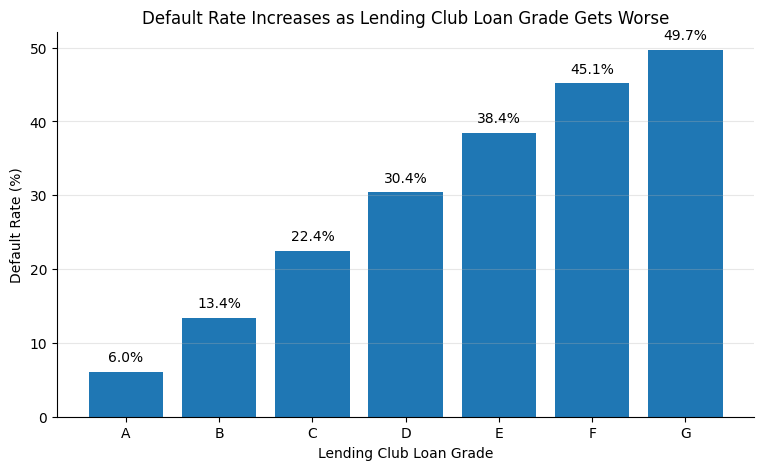

In [112]:

data = Accepted_Lending_Club_Data.copy()


# Looking if Grades of Loans Affect the Loan Default Risk

# Keep loans with a clear final outcome
finished_loans = data[data["loan_status"].isin([
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
])].copy()

# Create default flag
finished_loans["defaulted"] = finished_loans["loan_status"].isin([
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]).astype(int)

# Calculate default rate by loan grade
default_by_grade = (
    finished_loans.groupby("grade")["defaulted"]
    .mean()
    .reset_index()
)

# Convert default rate to percent
default_by_grade["default_rate_percent"] = default_by_grade["defaulted"] * 100

# Sort grades in order
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
default_by_grade["grade"] = pd.Categorical(
    default_by_grade["grade"],
    categories=grade_order,
    ordered=True
)
default_by_grade = default_by_grade.sort_values("grade")

# Create the bar chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    default_by_grade["grade"],
    default_by_grade["default_rate_percent"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Default Rate Increases as Lending Club Loan Grade Gets Worse")
plt.xlabel("Lending Club Loan Grade")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()